Elige una acción:
0: BAC
1: JPM
2: PLD
3: KHC
Ingresa el número: 0


/tmp/ipykernel_215/3725295325.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_stock = yf.download(tickers=ticker, start=start_date, end=end_date, progress=False)



Datos descargados para BAC: 4752 días
Última fecha disponible: 2026-03-03



Ajustando modelo ARIMA óptimo en todos los datos...
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=7297.805, Time=8.40 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=7292.651, Time=0.57 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=7294.650, Time=0.19 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=7294.650, Time=2.48 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=7290.832, Time=0.23 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=7296.651, Time=1.44 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 13.360 seconds
Mejor orden ARIMA encontrado: (0, 1, 0)

Generando forecast para los próximos 14 días hábiles...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is av


=== FORECAST NUMÉRICO - Próximos 14 días hábiles ===
           Fecha  Precio Predicho  Límite Inferior (95% CI)  Límite Superior (95% CI)
2026-03-04 (Wed)            49.69                     47.54                     51.83
2026-03-05 (Thu)            49.69                     47.67                     51.71
2026-03-06 (Fri)            49.69                     47.78                     51.59
2026-03-09 (Mon)            49.69                     47.89                     51.49
2026-03-10 (Tue)            49.69                     48.00                     51.38
2026-03-11 (Wed)            49.69                     48.09                     51.29
2026-03-12 (Thu)            49.69                     48.18                     51.19
2026-03-13 (Fri)            49.69                     48.27                     51.11
2026-03-16 (Mon)            49.69                     48.35                     51.03
2026-03-17 (Tue)            49.69                     48.43                     50.95


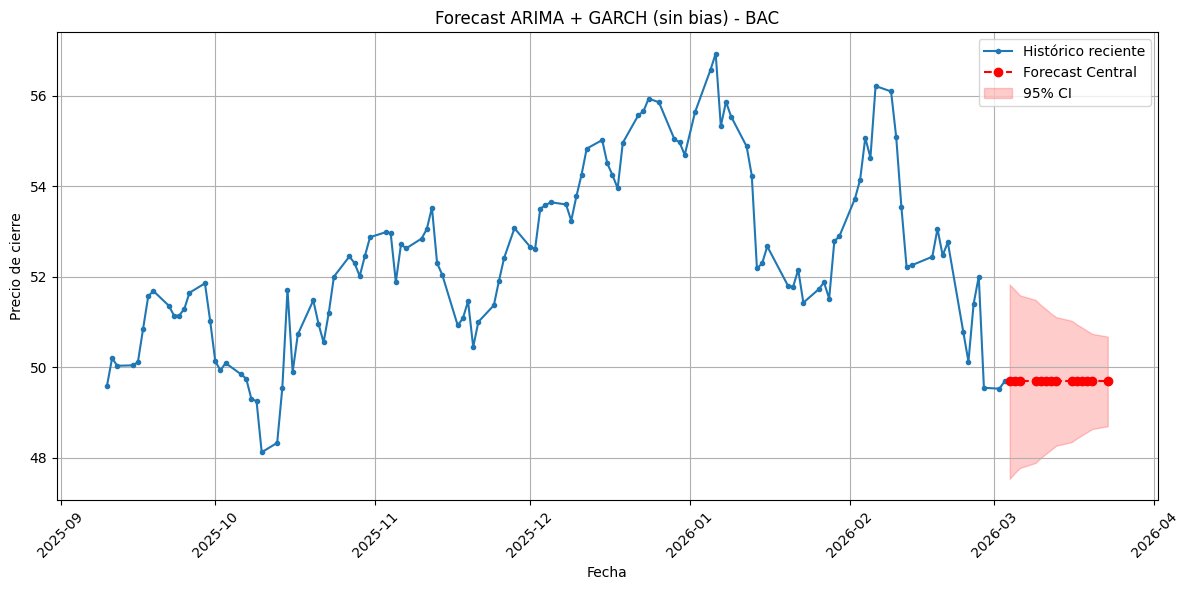


=== ESTADÍSTICAS DEL FORECAST ===
Precio actual (último cierre): 49.69
Promedio predicho (14 días):     49.69
Desviación estándar:             0.00
Mínimo predicho:                 49.69
Máximo predicho:                 49.69

=== DECISIÓN DE INVERSIÓN ===
Aumento significativo → COMPRAR (BUY)


/tmp/ipykernel_215/3725295325.py:135: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`



In [3]:
#GARCH

!pip install yfinance pmdarima arch plotly -q

import numpy as np
import pandas as pd
import yfinance as yf
import datetime
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from pmdarima import auto_arima
from arch import arch_model

# ============================= Parámetros =============================
stock_options = ['BAC', 'JPM', 'PLD', 'KHC']
stock_names   = ['BAC', 'JPM', 'PLD', 'KHC']

print("Elige una acción:")
for i, name in enumerate(stock_names):
    print(f"{i}: {name}")

choice = int(input("Ingresa el número: "))
ticker = stock_options[choice]
stock_name = stock_names[choice]

# Fechas (puedes cambiarlas)
start_date = '2007-04-13'
end_date   = '2026-03-04'   # Colab descargará hasta la fecha disponible real

# ============================= Descarga de datos =============================
df_stock = yf.download(tickers=ticker, start=start_date, end=end_date, progress=False)

if df_stock.empty:
    raise ValueError("No se encontraron datos para este ticker.")

# Aplanar columnas si es necesario
if isinstance(df_stock.columns, pd.MultiIndex):
    df_stock.columns = df_stock.columns.droplevel(1)

df = df_stock[['Open', 'High', 'Low',  'Close']].copy()
print(f"\nDatos descargados para {stock_name}: {len(df)} días")
print(f"Última fecha disponible: {df.index[-1].date()}")

# ============================= Gráfico Candlestick =============================
fig_candle = go.Figure(data=go.Candlestick(
    x=df.index,
    open=df['Open'], high=df['High'], low=df['Low'], close=df[ 'Close'],
    name=stock_name
))
fig_candle.update_layout(title=f'Precio Histórico - {stock_name}', xaxis_rangeslider_visible=False)
fig_candle.show()

# ============================= Modelo ARIMA final (todo el histórico) =============================
print("\nAjustando modelo ARIMA óptimo en todos los datos...")
arima_model = auto_arima(df[ 'Close'],
                         seasonal=False,
                         stepwise=True,
                         max_p=5, max_q=5, max_d=2,
                         trace=True,
                         error_action='ignore',
                         suppress_warnings=True)

arima_model.fit(df[ 'Close'])
print(f"Mejor orden ARIMA encontrado: {arima_model.order}")

# ============================= Forecast 14 días hábiles =============================
print("\nGenerando forecast para los próximos 14 días hábiles...")

last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=14, freq='B')  # Business days

future_preds = []
future_lower = []
future_upper = []
current_series = df[ 'Close'].copy()  # Serie que iremos actualizando

for i in range(14):
    # Predicción ARIMA (un paso adelante)
    pred_mean = arima_model.predict(n_periods=1).item()

    # Residuales del modelo actual
    resid = arima_model.resid()

    # GARCH con mean='Zero' para no sesgar
    adjustment = 0.0
    vol = 0.0
    if len(resid) > 30:
        garch = arch_model(resid, mean='Zero', vol='Garch', p=1, q=1, dist='Normal')
        garch_fit = garch.fit(disp='off', show_warning=False)
        # Usamos la MEDIA de GARCH (~0, sin bias)
        adjustment = garch_fit.forecast(horizon=1).mean.values[-1, 0]
        # Volatilidad para intervalos de confianza
        vol = np.sqrt(garch_fit.forecast(horizon=1).variance.values[-1, 0])

    pred = pred_mean + adjustment
    lower = pred - 1.96 * vol
    upper = pred + 1.96 * vol

    future_preds.append(round(pred, 2))
    future_lower.append(round(lower, 2))
    future_upper.append(round(upper, 2))

    # Agregamos la predicción a la serie y volvemos a ajustar (rolling forecast realista)
    next_date = future_dates[i]
    current_series[next_date] = pred
    arima_model.fit(current_series)

# ============================= Tabla numérica del forecast =============================
forecast_df = pd.DataFrame({
    'Fecha': future_dates.strftime('%Y-%m-%d (%a)'),
    'Precio Predicho': future_preds,
    'Límite Inferior (95% CI)': future_lower,
    'Límite Superior (95% CI)': future_upper
})

print("\n=== FORECAST NUMÉRICO - Próximos 14 días hábiles ===")
print(forecast_df.to_string(index=False))

# ============================= Gráfico final =============================
plt.figure(figsize=(12, 6))
plt.plot(df[ 'Close'][-120:], label='Histórico reciente', marker='.')
plt.plot(future_dates, future_preds, label='Forecast Central', marker='o', linestyle='--', color='red')
plt.fill_between(future_dates, future_lower, future_upper, color='red', alpha=0.2, label='95% CI')
plt.title(f'Forecast ARIMA + GARCH (sin bias) - {stock_name}')
plt.xlabel('Fecha')
plt.ylabel('Precio de cierre')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================= Estadísticas y decisión =============================
forecast_values = np.array(future_preds)
current_price = df[ 'Close'][-1]

avg_forecast = np.mean(forecast_values)
std_forecast = np.std(forecast_values)
max_forecast = np.max(forecast_values)
min_forecast = np.min(forecast_values)
potential_up   = max_forecast - current_price
potential_down = current_price - min_forecast

print("\n=== ESTADÍSTICAS DEL FORECAST ===")
print(f"Precio actual (último cierre): {current_price:.2f}")
print(f"Promedio predicho (14 días):     {avg_forecast:.2f}")
print(f"Desviación estándar:             {std_forecast:.2f}")
print(f"Mínimo predicho:                 {min_forecast:.2f}")
print(f"Máximo predicho:                 {max_forecast:.2f}")

print("\n=== DECISIÓN DE INVERSIÓN ===")
if potential_up > potential_down:
    if potential_up > std_forecast * 1.5:  # Umbral conservador
        print("Aumento significativo → COMPRAR (BUY)")
    else:
        print("Ligero aumento → MANTENER (HOLD)")
else:
    if potential_down > std_forecast * 1.5:
        print("Caída significativa → VENDER EN CORTO (SHORT)")
    else:
        print("Ligera caída → MANTENER (HOLD)")